# Aggregate guide-outlier tables

Reads `targeting_outlier_table.csv` and `non_targeting_outlier_table.csv` from each production dataset's `energy_distance/` run directory and stacks them into one long TSV.

**Input:** `datasets/<dataset_id>/<run_label>/energy_distance/{targeting,non_targeting}_outlier_table.csv`  
**Output:** `results/aggregate_guide_outliers/guide_outliers_long.tsv`

Columns: `dataset_id`, `dataset_short`, `run_label`, `guide_id`, `pval_outlier`, `is_targeting`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/cellar/users/aklie/projects/tf_perturb_seq")
sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

DATASETS = PROJECT_ROOT / "datasets"
EDIST = PROJECT_ROOT / "docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/edist"
OUT_DIR = EDIST / "results" / "aggregate_guide_outliers"
OUT_DIR.mkdir(parents=True, exist_ok=True)

dataset_colors = load_colors("production_TF-Perturb-seq", "dataset_colors")

# (dataset_id, run_label, short_name) — canonical production runs per README
RUNS = [
    ("Hon_WTC11-cardiomyocyte-differentiation_TF-Perturb-seq",          "2026_04_19_no_spacer",      "HonCM"),
    ("Huangfu_HUES8-definitive-endoderm-differentiation_TF-Perturb-seq", "muddy_penguin",            "HuangfuDE"),
    ("Huangfu_HUES8-embryonic-stemcell-differentiation_TF-Perturb-seq",  "sceptre_v1",               "HuangfuESC"),
    ("Gersbach_WTC11-hepatocyte-differentiation_TF-Perturb-seq",         "sara_synapse_syn74842722", "GersbachHep"),
]
DATASET_ORDER = [s for _, _, s in RUNS]
SHORT_TO_FULL = {s: d for d, _, s in RUNS}
COLORS = {s: dataset_colors[SHORT_TO_FULL[s]] for s in DATASET_ORDER}
OUTLIER_THRESHOLD = 0.05

print(f"OUT_DIR: {OUT_DIR}")


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


OUT_DIR: /cellar/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/edist/results/aggregate_guide_outliers


In [2]:
def read_outlier(path: Path, *, is_targeting: bool) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0)
    df.index.name = "guide_id"
    df = df.reset_index()
    df["is_targeting"] = is_targeting
    return df

frames = []
for dataset_id, run_label, short in RUNS:
    ed = DATASETS / dataset_id / run_label / "energy_distance"
    targ = ed / "targeting_outlier_table.csv"
    ntc  = ed / "non_targeting_outlier_table.csv"
    if not targ.is_file() or not ntc.is_file():
        print(f"  [skip] {short}: missing files under {ed.relative_to(PROJECT_ROOT)}")
        continue
    a = read_outlier(targ, is_targeting=True)
    b = read_outlier(ntc,  is_targeting=False)
    sub = pd.concat([a, b], ignore_index=True)
    sub.insert(0, "dataset_short", short)
    frames.append(sub)
    print(f"  {short:<12} {run_label:<28}  targeting={len(a):>6}  ntc={len(b):>4}")

if not frames:
    raise SystemExit("no outlier tables found")

long = pd.concat(frames, ignore_index=True)
long["is_outlier"] = long["pval_outlier"] < OUTLIER_THRESHOLD
print(f"\ncombined: {len(long):,} rows × {len(long.columns)} cols")
long.head()


  HonCM        2026_04_19_no_spacer          targeting= 13534  ntc= 600
  HuangfuDE    muddy_penguin                 targeting= 13534  ntc= 600
  HuangfuESC   sceptre_v1                    targeting= 13534  ntc= 600
  GersbachHep  sara_synapse_syn74842722      targeting= 13457  ntc= 599

combined: 56,458 rows × 5 cols


,dataset_short,guide_id,pval_outlier,is_targeting,is_outlier
0,HonCM,AARS#chr16:70289419-70289437(-),1.0,True,False
1,HonCM,AARS#chr16:70289477-70289495(-),1.0,True,False
2,HonCM,CD151#chr11:833006-833024(+),1.0,True,False
3,HonCM,CD151#chr11:833042-833060(-),1.0,True,False
4,HonCM,DNAJC19#chr3:180989327-180989345(-),1.0,True,False


In [3]:
# Per-dataset outlier breakdown at pval_outlier < OUTLIER_THRESHOLD
summary = (long.groupby(["dataset_short", "is_targeting"])
                .agg(n_guides=("guide_id", "size"),
                     n_outlier=("is_outlier", "sum"))
                .assign(pct_outlier=lambda d: 100 * d["n_outlier"] / d["n_guides"])
                .round(2))
summary


n_guides  n_outlier  pct_outlier
dataset_short is_targeting                                  
GersbachHep   False              599          0         0.00
              True             13457          0         0.00
HonCM         False              600         31         5.17
              True             13534        910         6.72
HuangfuDE     False              600         46         7.67
              True             13534        460         3.40
HuangfuESC    False              600         51         8.50
              True             13534       1270         9.38

In [4]:
out = OUT_DIR / "guide_outliers_long.tsv"
long.to_csv(out, sep="\t", index=False)
print(f"wrote {out.relative_to(EDIST)}  ({len(long):,} rows)")


wrote results/aggregate_guide_outliers/guide_outliers_long.tsv  (56,458 rows)


## Raw outlier counts per dataset

Outlier = `pval_outlier < 0.05`. Left: counts split into Targeting vs NTC. Right: same as percentage of guides in each class. Bars colored by the production dataset palette.


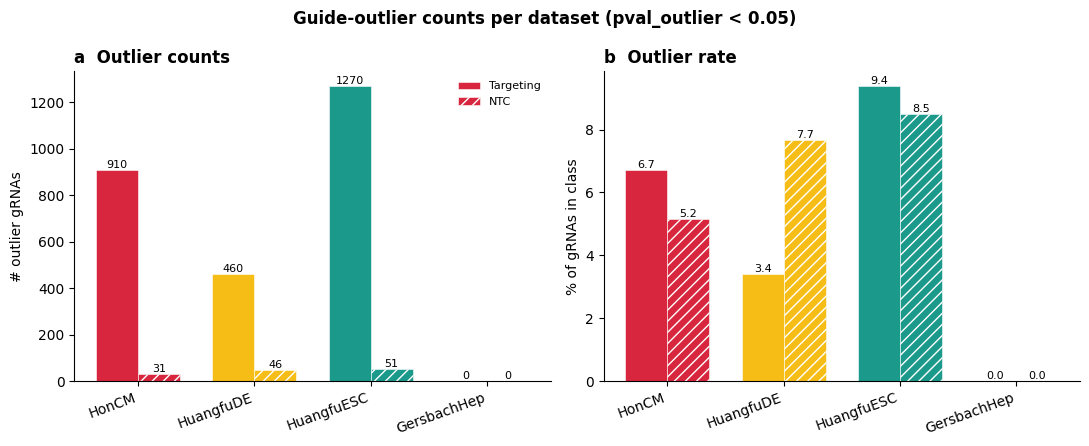

wrote outlier_counts.{pdf,png}


In [5]:
def outlier_count_panels(ax_left, ax_right, *, datasets, df_long):
    classes = [(True, "Targeting"), (False, "NTC")]
    width = 0.36
    x = np.arange(len(datasets))

    for j, (is_targ, label) in enumerate(classes):
        n_outlier, n_total = [], []
        for ds in datasets:
            sub = df_long[(df_long["dataset_short"] == ds) & (df_long["is_targeting"] == is_targ)]
            n_total.append(len(sub))
            n_outlier.append(int(sub["is_outlier"].sum()))
        n_outlier = np.array(n_outlier)
        n_total   = np.array(n_total)
        with np.errstate(divide="ignore", invalid="ignore"):
            pct = np.where(n_total > 0, 100 * n_outlier / n_total, 0)
        offset = (j - 0.5) * width
        face   = [COLORS[d] for d in datasets]
        hatch  = "" if is_targ else "///"
        bars_l = ax_left.bar(x + offset, n_outlier, width=width, color=face,
                             edgecolor="white", linewidth=0.4, hatch=hatch, label=label)
        bars_r = ax_right.bar(x + offset, pct,        width=width, color=face,
                              edgecolor="white", linewidth=0.4, hatch=hatch)
        for xi, val in zip(x + offset, n_outlier):
            ax_left.text(xi, val, f"{val}", ha="center", va="bottom", fontsize=8)
        for xi, val in zip(x + offset, pct):
            ax_right.text(xi, val, f"{val:.1f}", ha="center", va="bottom", fontsize=8)

    for ax, ylabel, title in [(ax_left,  "# outlier gRNAs",       "a  Outlier counts"),
                              (ax_right, "% of gRNAs in class",   "b  Outlier rate")]:
        ax.set_xticks(x); ax.set_xticklabels(datasets, rotation=20, ha="right")
        ax.set_ylabel(ylabel)
        ax.set_title(title, loc="left", fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
    ax_left.legend(frameon=False, fontsize=8, loc="upper right")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
outlier_count_panels(ax1, ax2, datasets=DATASET_ORDER, df_long=long)
fig.suptitle(f"Guide-outlier counts per dataset (pval_outlier < {OUTLIER_THRESHOLD})", fontweight="bold")
plt.tight_layout()
for ext in ("pdf", "png"):
    out = OUT_DIR / f"outlier_counts.{ext}"
    fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"wrote outlier_counts.{{pdf,png}}")


## UpSet of overlapping outlier gRNAs

Set membership = `pval_outlier < 0.05`. Targeting and NTC gRNAs plotted separately — the same gRNA ID across datasets refers to the same library member (libraries match across the four production datasets, Gersbach Hep just drops a handful).


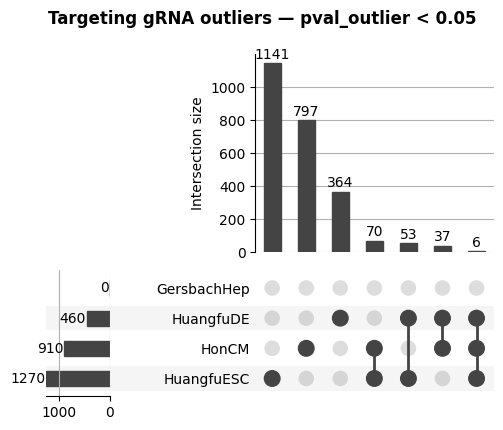

Targeting gRNA outliers — pval_outlier < 0.05 — per-dataset outlier counts: HonCM=910, HuangfuDE=460, HuangfuESC=1270, GersbachHep=0


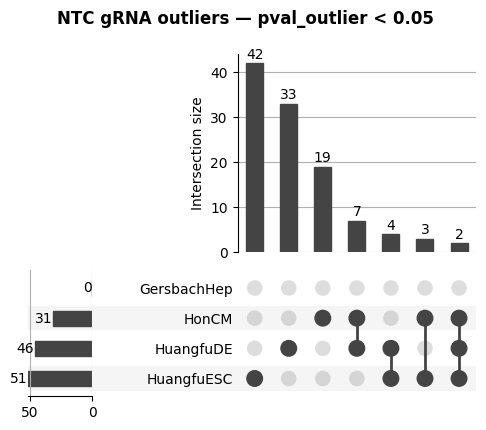

NTC gRNA outliers — pval_outlier < 0.05 — per-dataset outlier counts: HonCM=31, HuangfuDE=46, HuangfuESC=51, GersbachHep=0


In [6]:
from upsetplot import UpSet, from_contents

def upset_for(df, *, title, out_stem):
    contents = {ds: set(df.loc[(df["dataset_short"] == ds) & df["is_outlier"], "guide_id"])
                for ds in DATASET_ORDER}
    sizes = {ds: len(s) for ds, s in contents.items()}
    if sum(sizes.values()) == 0:
        print(f"  [skip] {title}: no outliers")
        return
    fig = plt.figure(figsize=(8, 4.5))
    up = UpSet(from_contents(contents), sort_by="cardinality",
               show_counts=True, facecolor="#444")
    up.plot(fig=fig)
    fig.suptitle(title, fontweight="bold")
    for ext in ("pdf", "png"):
        out = OUT_DIR / f"{out_stem}.{ext}"
        fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"{title} — per-dataset outlier counts: " + ", ".join(f"{k}={v}" for k, v in sizes.items()))

upset_for(long[long["is_targeting"]],
          title=f"Targeting gRNA outliers — pval_outlier < {OUTLIER_THRESHOLD}",
          out_stem="upset_targeting_outliers")

upset_for(long[~long["is_targeting"]],
          title=f"NTC gRNA outliers — pval_outlier < {OUTLIER_THRESHOLD}",
          out_stem="upset_ntc_outliers")
